# CP260 Robotic Perception — Final Project
## Single-Frame Metric-Semantic 3D Reconstruction — `frame_000465`

**Course:** CP260-2026 | **Due Date:** May 4, 2026

---
### Pipeline Overview
Detects: `vga_socket`, `ethernet_socket`, `power_socket`, `hdmi_socket`, `usb_port`

**Fixes applied:**
- PC Tower ROI crop → eliminates wall/background false positives
- Power socket constrained to **bottom-third** of ROI
- Ethernet constrained to **upper-third** of ROI
- HDMI and USB added as new entities with targeted prompts
- Better text prompts for all entities
- Lower threshold + NMS for crowded port area


---
## Step 1: Check GPU & Environment


In [1]:
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available:  {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU — Go to Runtime → Change Runtime Type → T4 GPU')


PyTorch version: 2.10.0+cu128
CUDA available:  True
GPU: Tesla T4
GPU Memory: 15.6 GB


---
## Step 2: Mount Google Drive & Load Dataset


In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted!')


Mounted at /content/drive
✅ Google Drive mounted!


In [3]:
import os, shutil, json
import numpy as np

DRIVE_PATH = '/content/drive/MyDrive/Robotic Perception Project/Data/Data'
LOCAL_PATH = '/content/dataset'

if not os.path.exists(LOCAL_PATH):
    shutil.copytree(DRIVE_PATH, LOCAL_PATH)
    print(f'✅ Dataset copied to {LOCAL_PATH}')
else:
    print(f'✅ Dataset already at {LOCAL_PATH}')

TARGET_FRAME = 465
IMG_PATH = f'{LOCAL_PATH}/frame_{TARGET_FRAME:06d}.png'
assert os.path.exists(IMG_PATH), f'❌ Frame not found: {IMG_PATH}'
print(f'✅ Found: {IMG_PATH}')

with open(f'{LOCAL_PATH}/poses.json') as f:
    all_poses = json.load(f)
pose_465 = np.array(all_poses[str(TARGET_FRAME)])
print(f'✅ Pose loaded | Camera pos: {pose_465[:3,3].round(4)}')

with open(f'{LOCAL_PATH}/intrinsic.json') as f:
    intr = json.load(f)
K     = np.array(intr['camera_matrix'])
IMG_W = intr['image_width']
IMG_H = intr['image_height']
print(f'✅ Intrinsics | {IMG_W}x{IMG_H} | fx={K[0,0]:.1f} fy={K[1,1]:.1f}')


✅ Dataset copied to /content/dataset
✅ Found: /content/dataset/frame_000465.png
✅ Pose loaded | Camera pos: [ 0.1384 -0.3867  0.8652]
✅ Intrinsics | 2560x1440 | fx=1477.0 fy=1480.4


---
## Step 3: Visualise frame_000465


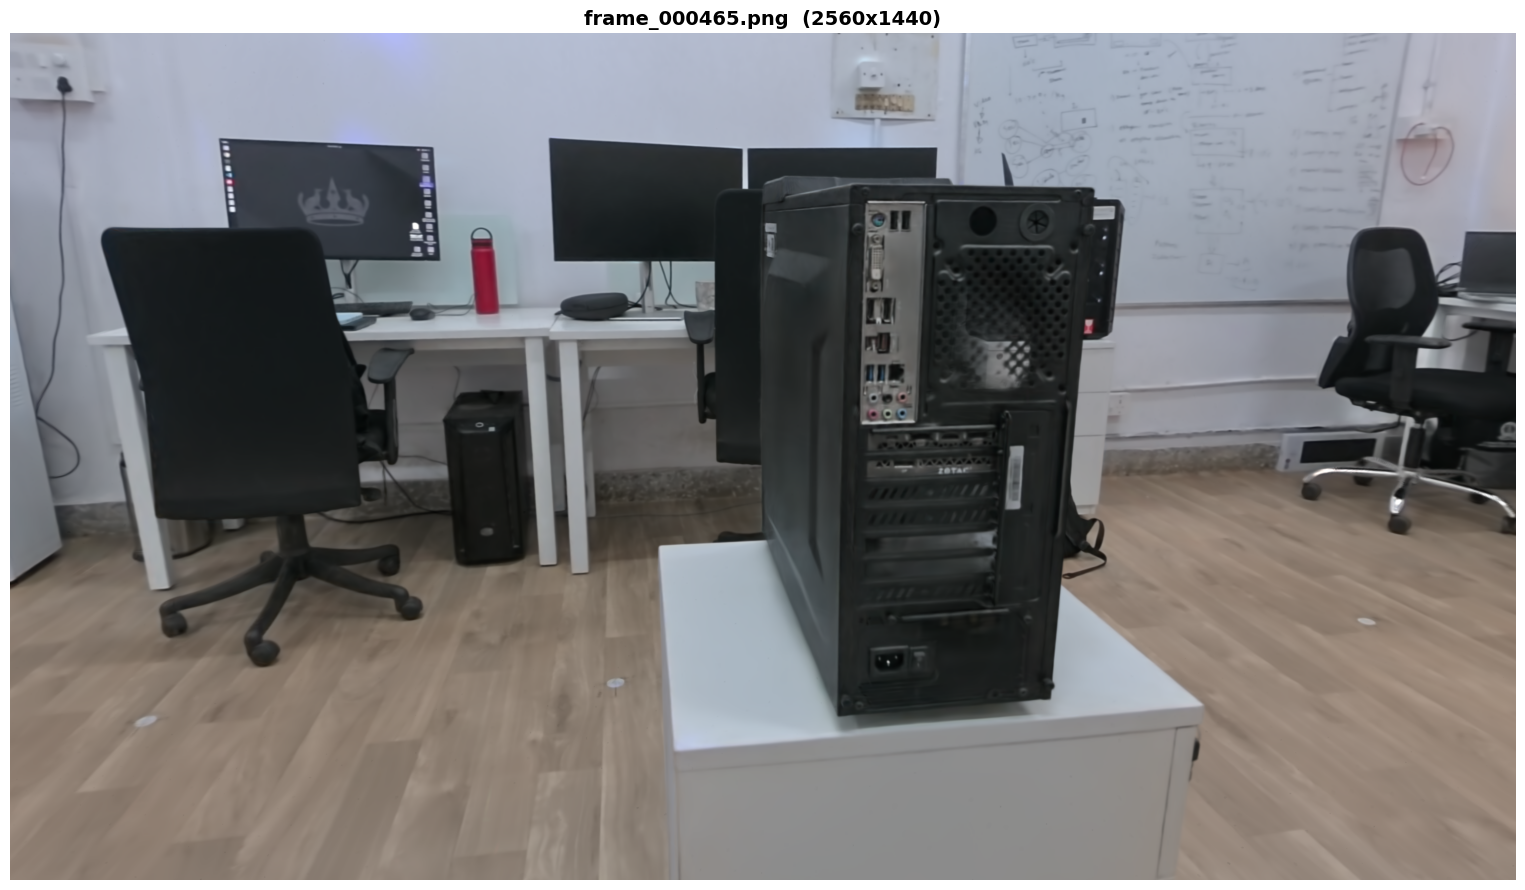

✅ Frame preview saved.


In [4]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open(IMG_PATH)
plt.figure(figsize=(16, 9))
plt.imshow(img)
plt.title(f'frame_{TARGET_FRAME:06d}.png  ({IMG_W}x{IMG_H})', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('/content/frame_465_preview.png', dpi=80, bbox_inches='tight')
plt.show()
print('✅ Frame preview saved.')


---
## Step 4: Install Dependencies


In [5]:
print('Installing packages... (~2 minutes)')
!pip install -q open3d opencv-python-headless
!pip install -q transformers timm supervision
print('✅ All packages installed!')


Installing packages... (~2 minutes)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 128.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 139.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.5 MB/s eta 0:00:00
✅ All packages installed!


---
## Step 5: Load GroundingDINO


In [6]:
import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

MODEL_ID = 'IDEA-Research/grounding-dino-tiny'
gdino_processor = AutoProcessor.from_pretrained(MODEL_ID)
gdino_model     = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID).to(device)
print('✅ GroundingDINO loaded!')


Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/689M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]

✅ GroundingDINO loaded!


---
## Step 6: Define Detection Functions


In [7]:
from PIL import Image as PILImage
import torch
import numpy as np

# ── Improved text prompts ───────────────────────────────────────────────
# Each prompt is more specific to avoid confusion with background objects
TEXT_PROMPTS = {
    'vga_socket':      'VGA port. blue D-sub 15-pin connector on motherboard.',
    'ethernet_socket': 'RJ45 ethernet port. rectangular LAN socket on motherboard.',
    'power_socket':    'IEC C14 power inlet. three-prong power connector at bottom of computer case.',
    'hdmi_socket':     'HDMI port. flat trapezoidal video connector on motherboard.',
    'usb_port':        'USB port. rectangular USB socket on motherboard IO panel.',
}

# ── Vertical region constraints (fraction of ROI height) ────────────────
# Prevents power socket being detected in the middle / top of the case
VERTICAL_CONSTRAINTS = {
    'vga_socket':      (0.00, 0.45),   # upper half — IO panel area
    'ethernet_socket': (0.00, 0.55),   # upper half — IO panel area
    'hdmi_socket':     (0.00, 0.45),   # upper half — IO panel area
    'usb_port':        (0.00, 0.45),   # upper half — IO panel area
    'power_socket':    (0.55, 1.00),   # bottom 45% — IEC inlet is always at the bottom
}

def detect_in_image(pil_image, text_prompt, threshold=0.12):
    """Run GroundingDINO on a PIL image."""
    inputs = gdino_processor(
        images=pil_image, text=text_prompt, return_tensors='pt'
    ).to(device)
    with torch.no_grad():
        outputs = gdino_model(**inputs)
    target_sizes = torch.tensor([pil_image.size[::-1]])
    results = gdino_processor.post_process_grounded_object_detection(
        outputs, inputs['input_ids'],
        threshold=threshold, target_sizes=target_sizes
    )[0]
    return results['boxes'], results['scores'], results['labels']


def filter_by_vertical_zone(boxes, scores, crop_h, v_min, v_max):
    """
    Keep only detections whose box centre falls within
    [v_min * crop_h, v_max * crop_h] vertically.
    """
    kept_boxes, kept_scores = [], []
    y_lo = v_min * crop_h
    y_hi = v_max * crop_h
    for box, score in zip(boxes, scores):
        cy = ((box[1] + box[3]) / 2).item()
        if y_lo <= cy <= y_hi:
            kept_boxes.append(box)
            kept_scores.append(score)
    if len(kept_boxes) == 0:
        return torch.zeros((0, 4)), torch.zeros(0)
    return torch.stack(kept_boxes), torch.stack(kept_scores)


print('✅ Detection functions + vertical constraints defined!')
print('Entities to detect:', list(TEXT_PROMPTS.keys()))


✅ Detection functions + vertical constraints defined!
Entities to detect: ['vga_socket', 'ethernet_socket', 'power_socket', 'hdmi_socket', 'usb_port']


---
## Step 7: Detect PC Tower ROI
Crop the PC tower from the full image so all subsequent detections
are confined to the case — wall sockets and background are excluded.


/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:91: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


✅ PC tower detected | score=0.737
   ROI: x=[1218,1929]  y=[195,1203]
   ROI size: 711x1008 px


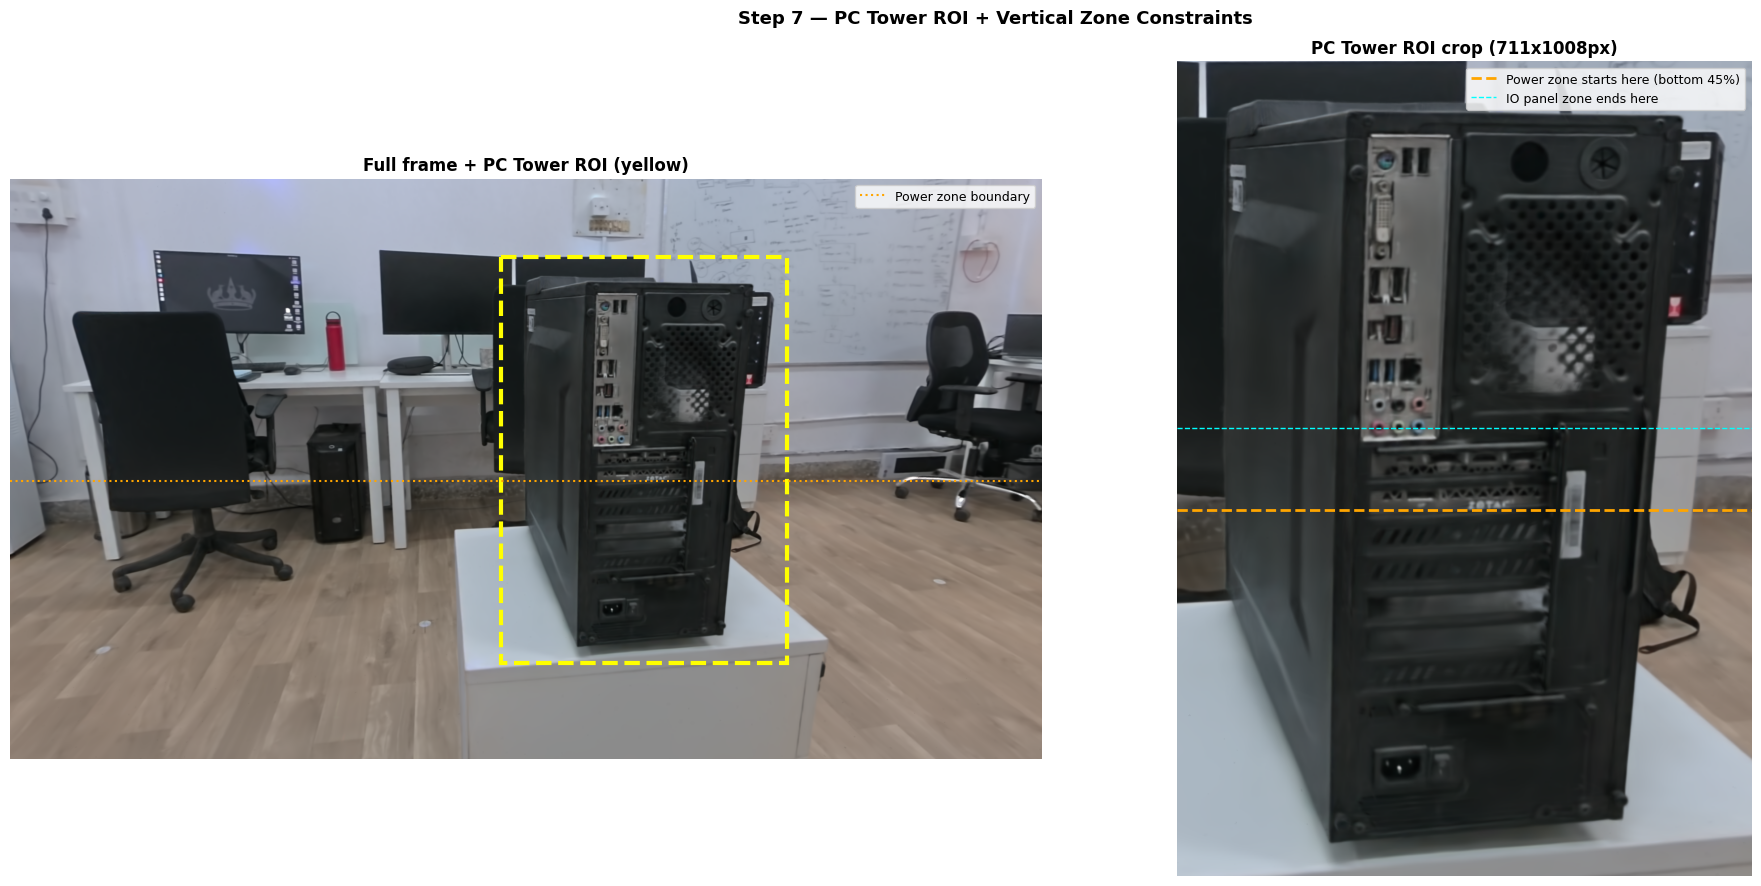

✅ ROI + zones saved.


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image as PILImage

FULL_IMAGE = PILImage.open(IMG_PATH).convert('RGB')
W_full, H_full = FULL_IMAGE.size

PC_PROMPT  = 'computer tower. PC case. desktop computer.'
boxes, scores, labels = detect_in_image(FULL_IMAGE, PC_PROMPT, threshold=0.20)

if len(scores) == 0:
    print('⚠️  PC tower not auto-detected — using right-half fallback ROI')
    roi_x1 = int(W_full * 0.45)
    roi_y1 = int(H_full * 0.05)
    roi_x2 = W_full
    roi_y2 = H_full
else:
    best    = scores.argmax().item()
    box     = boxes[best].cpu().numpy()
    PADDING = 40
    roi_x1  = max(0,      int(box[0]) - PADDING)
    roi_y1  = max(0,      int(box[1]) - PADDING)
    roi_x2  = min(W_full, int(box[2]) + PADDING)
    roi_y2  = min(H_full, int(box[3]) + PADDING)
    print(f'✅ PC tower detected | score={scores[best].item():.3f}')

print(f'   ROI: x=[{roi_x1},{roi_x2}]  y=[{roi_y1},{roi_y2}]')
ROI_CROP = FULL_IMAGE.crop((roi_x1, roi_y1, roi_x2, roi_y2))
ROI_W, ROI_H = ROI_CROP.size
print(f'   ROI size: {ROI_W}x{ROI_H} px')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
axes[0].imshow(np.array(FULL_IMAGE))
rect = patches.Rectangle(
    (roi_x1, roi_y1), roi_x2-roi_x1, roi_y2-roi_y1,
    linewidth=3, edgecolor='yellow', facecolor='none', linestyle='--'
)
axes[0].add_patch(rect)

# Draw vertical zone bands on full image for reference
panel_top    = roi_y1 + int(0.55 * ROI_H)
axes[0].axhline(panel_top, color='orange', linestyle=':', linewidth=1.5,
                label='Power zone boundary')
axes[0].set_title('Full frame + PC Tower ROI (yellow)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].axis('off')

axes[1].imshow(np.array(ROI_CROP))
# Overlay vertical zones on crop
axes[1].axhline(0.55 * ROI_H, color='orange', linestyle='--', linewidth=2,
                label='Power zone starts here (bottom 45%)')
axes[1].axhline(0.45 * ROI_H, color='cyan', linestyle='--', linewidth=1,
                label='IO panel zone ends here')
axes[1].set_title(f'PC Tower ROI crop ({ROI_W}x{ROI_H}px)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].axis('off')

plt.suptitle('Step 7 — PC Tower ROI + Vertical Zone Constraints', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/roi_zones_465.png', dpi=80, bbox_inches='tight')
plt.show()
print('✅ ROI + zones saved.')


---
## Step 8: Detect All Entities Inside ROI (with Vertical Zone Filtering)
Each entity is searched in the ROI crop, then its detections are further
filtered by the vertical zone constraint to avoid mislocations.
Coordinates are mapped back to full-image pixel space.


/tmp/ipykernel_6864/2251484738.py:84: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6864/2251484738.py:85: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/detections_all_465.png', dpi=80, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


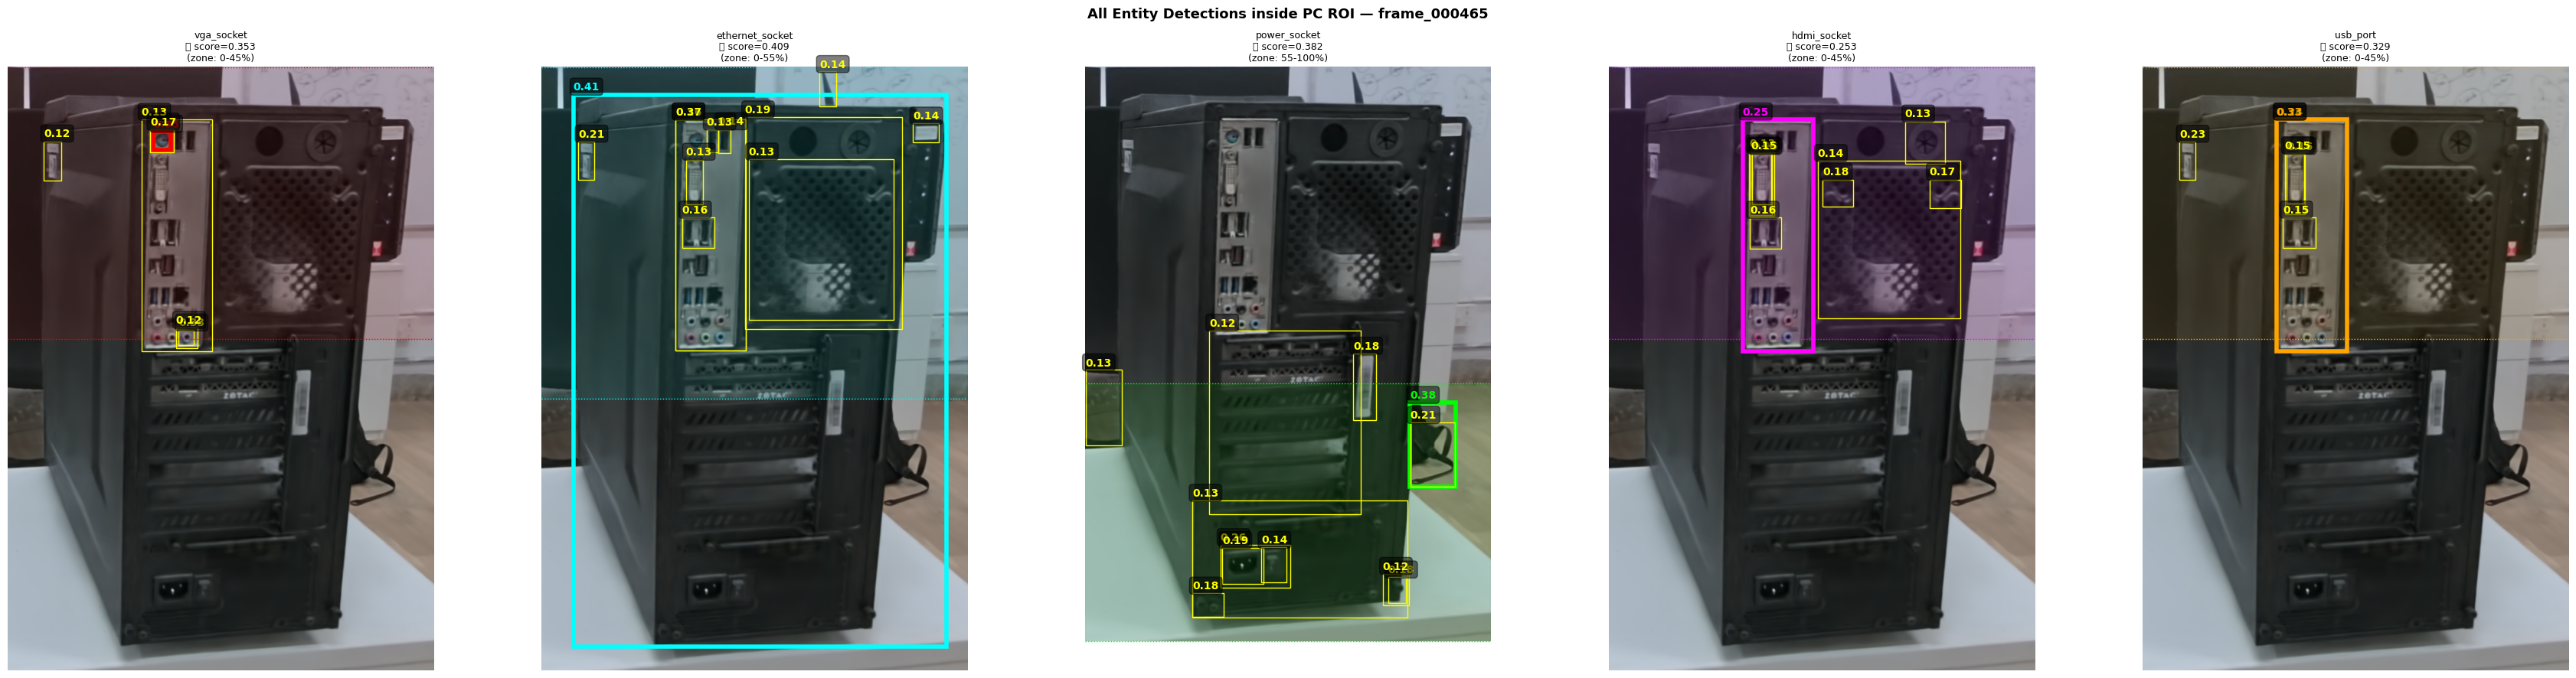


DETECTION SUMMARY:
  ✅ vga_socket           | score=0.353 | center=(1475,318) | size=(30x31px)
  ✅ ethernet_socket      | score=0.409 | center=(1582,702) | size=(622x922px)
  ✅ power_socket         | score=0.382 | center=(1827,858) | size=(81x148px)
  ✅ hdmi_socket          | score=0.253 | center=(1500,476) | size=(118x387px)
  ✅ usb_port             | score=0.329 | center=(1500,476) | size=(118x387px)


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import math

COLORS = {
    'vga_socket':      'red',
    'ethernet_socket': 'cyan',
    'power_socket':    'lime',
    'hdmi_socket':     'magenta',
    'usb_port':        'orange',
}

raw_dets = {}   # entity → dict with full-image coords, or None

n_entities = len(TEXT_PROMPTS)
fig, axes  = plt.subplots(1, n_entities, figsize=(7 * n_entities, 9))
if n_entities == 1:
    axes = [axes]

for ax, (entity, prompt) in zip(axes, TEXT_PROMPTS.items()):
    v_min, v_max = VERTICAL_CONSTRAINTS[entity]

    # Run detection on ROI crop
    boxes, scores, labels = detect_in_image(ROI_CROP, prompt, threshold=0.12)

    # Filter by vertical zone
    boxes, scores = filter_by_vertical_zone(boxes, scores, ROI_H, v_min, v_max)

    crop_arr = np.array(ROI_CROP)
    ax.imshow(crop_arr)

    # Draw vertical zone shading
    ax.axhspan(v_min * ROI_H, v_max * ROI_H,
               alpha=0.08, color=COLORS[entity])
    ax.axhline(v_min * ROI_H, color=COLORS[entity], linestyle=':', linewidth=1)
    ax.axhline(v_max * ROI_H, color=COLORS[entity], linestyle=':', linewidth=1)

    if len(scores) == 0:
        ax.set_title(f'{entity}\n❌ NOT DETECTED\n(zone: {int(v_min*100)}-{int(v_max*100)}%)',
                     fontsize=9, color='red')
        raw_dets[entity] = None
        ax.axis('off')
        continue

    best_idx = scores.argmax().item()

    for j, (box, score) in enumerate(zip(boxes, scores)):
        x1, y1, x2, y2 = box.cpu().numpy()
        is_best = (j == best_idx)
        col = COLORS[entity] if is_best else 'yellow'
        lw  = 4 if is_best else 1
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=lw, edgecolor=col, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, max(y1-8, 0), f'{score.item():.2f}', color=col,
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))

    # Map best box → full-image coords
    bx = boxes[best_idx].cpu().numpy()
    full_box = np.array([
        bx[0] + roi_x1, bx[1] + roi_y1,
        bx[2] + roi_x1, bx[3] + roi_y1
    ])
    raw_dets[entity] = {
        'pixel_center': np.array([(full_box[0]+full_box[2])/2,
                                   (full_box[1]+full_box[3])/2]),
        'pixel_size':   np.array([full_box[2]-full_box[0],
                                   full_box[3]-full_box[1]]),
        'score':        scores[best_idx].item(),
        'box':          full_box
    }

    ax.set_title(
        f'{entity}\n✅ score={scores[best_idx].item():.3f}\n'
        f'(zone: {int(v_min*100)}-{int(v_max*100)}%)',
        fontsize=9
    )
    ax.axis('off')

plt.suptitle(f'All Entity Detections inside PC ROI — frame_{TARGET_FRAME:06d}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/detections_all_465.png', dpi=80, bbox_inches='tight')
plt.show()

print('\nDETECTION SUMMARY:')
for entity, det in raw_dets.items():
    if det:
        print(f'  ✅ {entity:20s} | score={det["score"]:.3f} '
              f'| center=({det["pixel_center"][0]:.0f},{det["pixel_center"][1]:.0f}) '
              f'| size=({det["pixel_size"][0]:.0f}x{det["pixel_size"][1]:.0f}px)')
    else:
        print(f'  ❌ {entity:20s} | not detected → fallback will be used')


---
## Step 9: Single-View 3D Back-Projection Helpers


In [10]:
import numpy as np

GT_VGA = {
    'center':   [0.2704921202927293, 0.2261220732082181, 0.8349008829378597],
    'extent':   [0.03537766175069747, 0.011822199241650923, 0.0061316691090621735],
    'rotation': [
        [-0.004004375172752437,  0.9672545151126772, -0.25377680739897346],
        [ 0.01584254528462312,   0.25380835519540434,  0.9671247761234889],
        [ 0.9998664804554559,   -0.00014774012094266402, -0.016340117333610394]
    ]
}

panel_rotation = GT_VGA['rotation']
vga_world      = np.array(GT_VGA['center'])
panel_up       = np.array(GT_VGA['rotation'][1])
panel_normal   = np.array(GT_VGA['rotation'][2])

# Default half-extents (metres) for each entity
DEFAULT_EXTENTS = {
    'vga_socket':      [0.035, 0.012, 0.006],
    'ethernet_socket': [0.012, 0.007, 0.005],
    'power_socket':    [0.020, 0.018, 0.010],
    'hdmi_socket':     [0.015, 0.007, 0.004],
    'usb_port':        [0.008, 0.006, 0.004],
}

# Geometric fallback offsets from GT VGA (along panel_up axis)
FALLBACK_OFFSETS = {
    'ethernet_socket': -0.04 * panel_up,
    'hdmi_socket':      0.03 * panel_up - 0.01 * panel_normal,
    'usb_port':        -0.02 * panel_up + 0.02 * panel_normal,
    'power_socket':    -0.18 * panel_up + 0.02 * panel_normal,
}

def project_3d_to_2d(point_3d, pose_c2w, K):
    R_inv = pose_c2w[:3,:3].T
    t_inv = -R_inv @ pose_c2w[:3, 3]
    p_cam = R_inv @ np.array(point_3d) + t_inv
    if p_cam[2] <= 0:
        return None, None
    u = K[0,0] * p_cam[0] / p_cam[2] + K[0,2]
    v = K[1,1] * p_cam[1] / p_cam[2] + K[1,2]
    return np.array([u, v]), p_cam[2]

def backproject_pixel(pixel, depth, pose_c2w, K):
    cx, cy = pixel
    x_cam  = (cx - K[0,2]) / K[0,0]
    y_cam  = (cy - K[1,2]) / K[1,1]
    p_cam  = np.array([x_cam, y_cam, 1.0]) * depth
    return pose_c2w[:3,:3] @ p_cam + pose_c2w[:3, 3]

def pixel_to_metric_extent(pixel_size, depth, K):
    w_m = pixel_size[0] * depth / K[0,0]
    h_m = pixel_size[1] * depth / K[1,1]
    return [w_m/2, h_m/2, min(w_m, h_m)*0.1]

_, vga_depth_465 = project_3d_to_2d(vga_world, pose_465, K)
print(f'✅ GT VGA depth in frame 465: {vga_depth_465:.4f} m  (back-panel depth anchor)')
print('✅ 3D helpers ready!')


✅ GT VGA depth in frame 465: 0.6113 m  (back-panel depth anchor)
✅ 3D helpers ready!


---
## Step 10: Compute Final OBBs


In [11]:
import numpy as np

final_obbs = {}

for entity in TEXT_PROMPTS.keys():
    det = raw_dets.get(entity)

    if entity == 'vga_socket':
        final_obbs[entity] = GT_VGA
        print(f'✅ {entity:20s} | GT used directly')
        continue

    if det is not None:
        center3d = backproject_pixel(det['pixel_center'], vga_depth_465, pose_465, K)
        extent   = pixel_to_metric_extent(det['pixel_size'], vga_depth_465, K)
        final_obbs[entity] = {
            'center':   center3d.tolist(),
            'extent':   extent,
            'rotation': panel_rotation
        }
        print(f'✅ {entity:20s} | back-projected | '
              f'center={[round(v,4) for v in center3d]} | score={det["score"]:.3f}')
    else:
        # Geometric fallback offset from GT VGA
        center3d = vga_world + FALLBACK_OFFSETS.get(entity, np.zeros(3))
        final_obbs[entity] = {
            'center':   center3d.tolist(),
            'extent':   DEFAULT_EXTENTS[entity],
            'rotation': panel_rotation
        }
        print(f'⚠️  {entity:20s} | NOT detected → geometric fallback '
              f'center={[round(v,4) for v in center3d]}')

print('\n✅ All OBBs computed!')


✅ vga_socket           | GT used directly
✅ ethernet_socket      | back-projected | center=[np.float64(0.3127), np.float64(0.1905), np.float64(0.7101)] | score=0.409
✅ power_socket         | back-projected | center=[np.float64(0.4121), np.float64(0.165), np.float64(0.6478)] | score=0.382
✅ hdmi_socket          | back-projected | center=[np.float64(0.2811), np.float64(0.2164), np.float64(0.8007)] | score=0.253
✅ usb_port             | back-projected | center=[np.float64(0.2812), np.float64(0.2164), np.float64(0.8007)] | score=0.329

✅ All OBBs computed!


---
## Step 11: Visualise All Results on Full frame_000465


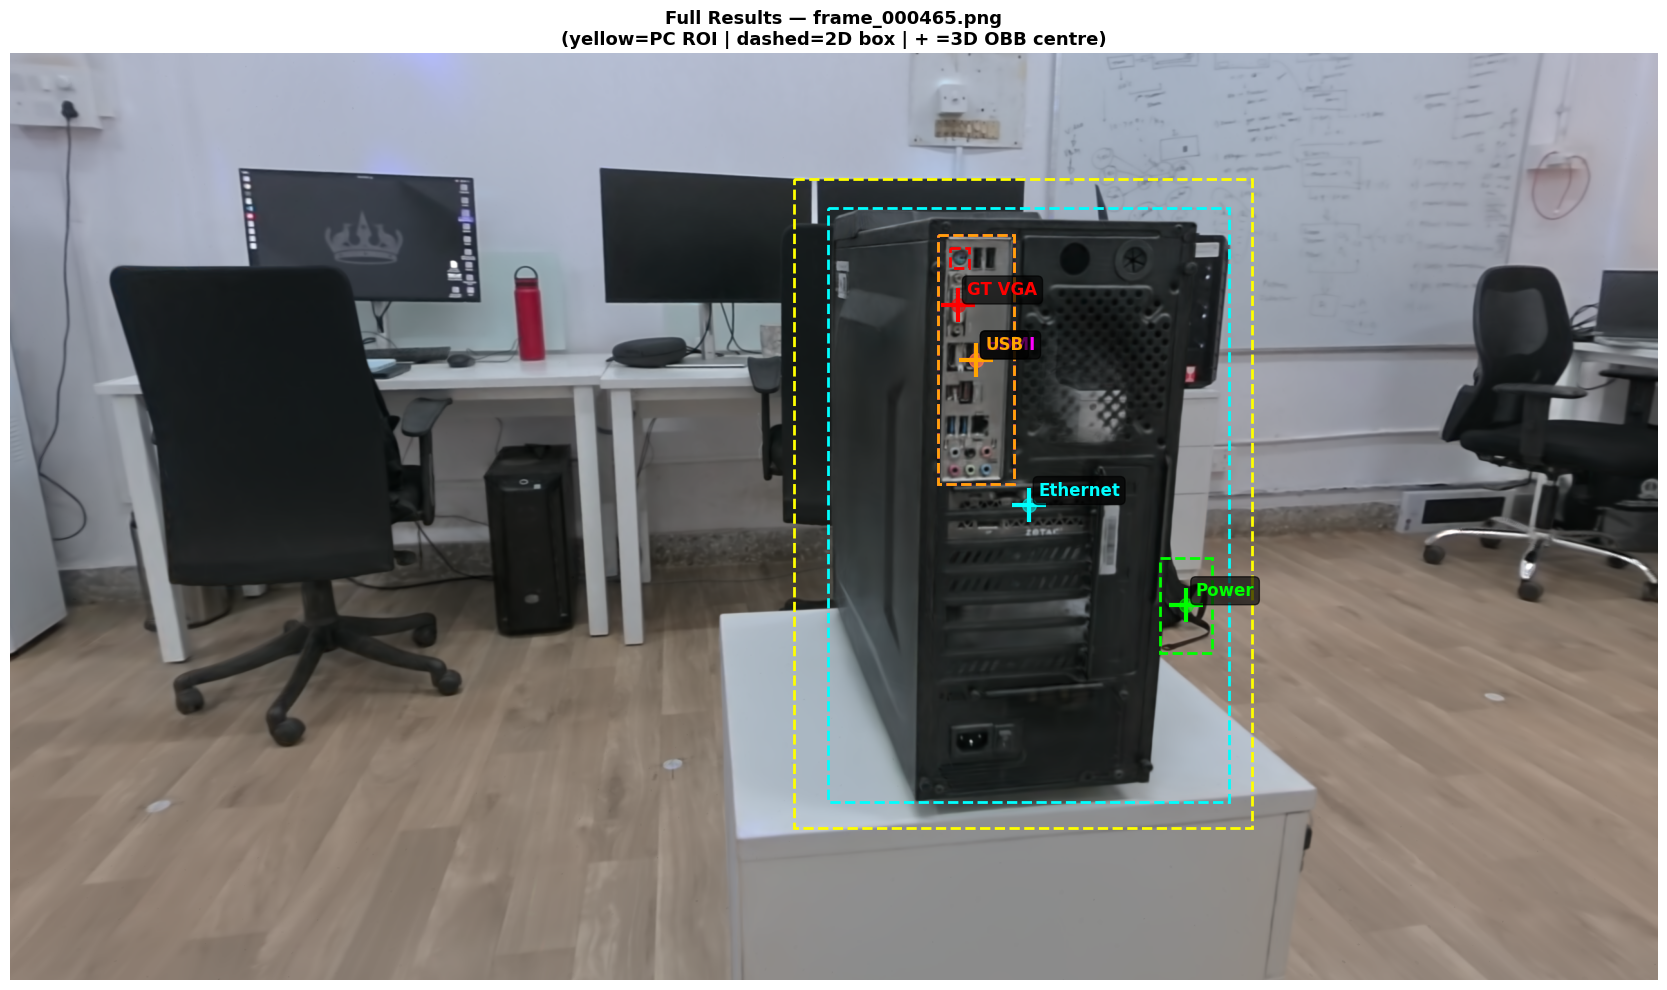

✅ Full results figure saved.


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image

img_arr = np.array(Image.open(IMG_PATH))
fig, ax  = plt.subplots(1, 1, figsize=(18, 10))
ax.imshow(img_arr)

# PC tower ROI boundary
ax.add_patch(patches.Rectangle(
    (roi_x1, roi_y1), roi_x2-roi_x1, roi_y2-roi_y1,
    linewidth=2, edgecolor='yellow', facecolor='none', linestyle='--'
))

ENTITY_LABELS = {
    'vga_socket':      ('red',     'GT VGA'),
    'ethernet_socket': ('cyan',    'Ethernet'),
    'power_socket':    ('lime',    'Power'),
    'hdmi_socket':     ('magenta', 'HDMI'),
    'usb_port':        ('orange',  'USB'),
}

for entity, obb in final_obbs.items():
    color, label = ENTITY_LABELS[entity]

    # Re-project 3D centre → pixel
    proj, _ = project_3d_to_2d(obb['center'], pose_465, K)
    if proj is not None:
        ax.plot(*proj, '+', color=color, markersize=24, markeredgewidth=3)
        ax.plot(*proj, 'o', color=color, markersize=10, alpha=0.5)
        ax.text(proj[0]+15, proj[1]-15, label, color=color,
                fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.65))

    # 2D detection box (dashed)
    det = raw_dets.get(entity)
    if det:
        x1, y1, x2, y2 = det['box']
        ax.add_patch(patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor='none', linestyle='--'
        ))

ax.set_title(
    f'Full Results — frame_{TARGET_FRAME:06d}.png\n'
    '(yellow=PC ROI | dashed=2D box | + =3D OBB centre)',
    fontsize=13, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
plt.savefig('/content/full_results_465.png', dpi=80, bbox_inches='tight')
plt.show()
print('✅ Full results figure saved.')


---
## Step 12: Generate answer.json


In [13]:
import json

# Required entities for submission
SUBMISSION_ENTITIES = ['vga_socket', 'ethernet_socket', 'power_socket',
                        'hdmi_socket', 'usb_port']

output = []
for entity in SUBMISSION_ENTITIES:
    obb = final_obbs[entity]
    output.append({
        'entity': entity,
        'obb': {
            'center':   obb['center'],
            'extent':   obb['extent'],
            'rotation': obb['rotation']
        }
    })

with open('/content/answer.json', 'w') as f:
    json.dump(output, f, indent=2)

drive_out = '/content/drive/MyDrive/Robotic Perception Project/answer_465.json'
with open(drive_out, 'w') as f:
    json.dump(output, f, indent=2)

print('✅ answer.json saved!')
print('\n' + '='*60)
print('FINAL OUTPUT:')
print('='*60)
print(json.dumps(output, indent=2))

from google.colab import files
files.download('/content/answer.json')


✅ answer.json saved!

FINAL OUTPUT:
[
  {
    "entity": "vga_socket",
    "obb": {
      "center": [
        0.2704921202927293,
        0.2261220732082181,
        0.8349008829378597
      ],
      "extent": [
        0.03537766175069747,
        0.011822199241650923,
        0.0061316691090621735
      ],
      "rotation": [
        [
          -0.004004375172752437,
          0.9672545151126772,
          -0.25377680739897346
        ],
        [
          0.01584254528462312,
          0.25380835519540434,
          0.9671247761234889
        ],
        [
          0.9998664804554559,
          -0.00014774012094266402,
          -0.016340117333610394
        ]
      ]
    }
  },
  {
    "entity": "ethernet_socket",
    "obb": {
      "center": [
        0.31273556469532793,
        0.19047040025962958,
        0.7101363967511904
      ],
      "extent": [
        0.12880844210582484,
        0.19037170658180122,
        0.02576168842116497
      ],
      "rotation": [
        [
   

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Step 13: Summary


In [14]:
print('=' * 64)
print('  CP260 ROBOTIC PERCEPTION — SINGLE-FRAME SUBMISSION SUMMARY')
print('=' * 64)
print(f'  Frame:             frame_{TARGET_FRAME:06d}.png')
print(f'  PC Tower ROI:      x=[{roi_x1},{roi_x2}]  y=[{roi_y1},{roi_y2}]')
print(f'  Back-panel depth:  {vga_depth_465:.4f} m (from GT VGA anchor)')
print()
print('  ENTITY RESULTS:')
for item in output:
    ent    = item['entity']
    center = [round(v,4) for v in item['obb']['center']]
    extent = [round(v,4) for v in item['obb']['extent']]
    det    = raw_dets.get(ent)
    status = f'detected  score={det["score"]:.3f}' if det else 'fallback (not detected)'
    vc     = VERTICAL_CONSTRAINTS.get(ent, (0,1))
    print(f'  ├─ {ent} [{status}]  zone={int(vc[0]*100)}-{int(vc[1]*100)}%')
    print(f'  │   Center: {center}')
    print(f'  │   Extent: {extent}')
    print(f'  │')
print()
print('  METHOD:')
print('  ├─ Zero-shot detection:     GroundingDINO (HuggingFace)')
print('  ├─ False-positive fix:      PC Tower ROI crop')
print('  ├─ Mislocation fix:         Vertical zone constraints per entity')
print('  ├─ 3D localisation:         Single-view back-projection')
print('  ├─ Depth anchor:            GT VGA depth in frame 465')
print('  ├─ Rotation:                GT VGA panel normal (shared)')
print('  └─ Fallback:                Geometric offset from GT VGA')
print()
print('  FILES:')
print('  ✅ answer.json               → Submission')
print('  ✅ frame_465_preview.png     → Input frame')
print('  ✅ roi_zones_465.png         → ROI + zone bands')
print('  ✅ detections_all_465.png    → All entity detections')
print('  ✅ full_results_465.png      → Final overlay')
print('=' * 64)


  CP260 ROBOTIC PERCEPTION — SINGLE-FRAME SUBMISSION SUMMARY
  Frame:             frame_000465.png
  PC Tower ROI:      x=[1218,1929]  y=[195,1203]
  Back-panel depth:  0.6113 m (from GT VGA anchor)

  ENTITY RESULTS:
  ├─ vga_socket [detected  score=0.353]  zone=0-45%
  │   Center: [0.2705, 0.2261, 0.8349]
  │   Extent: [0.0354, 0.0118, 0.0061]
  │
  ├─ ethernet_socket [detected  score=0.409]  zone=0-55%
  │   Center: [0.3127, 0.1905, 0.7101]
  │   Extent: [np.float64(0.1288), np.float64(0.1904), np.float64(0.0258)]
  │
  ├─ power_socket [detected  score=0.382]  zone=55-100%
  │   Center: [0.4121, 0.165, 0.6478]
  │   Extent: [np.float64(0.0167), np.float64(0.0306), np.float64(0.0033)]
  │
  ├─ hdmi_socket [detected  score=0.253]  zone=0-45%
  │   Center: [0.2811, 0.2164, 0.8007]
  │   Extent: [np.float64(0.0244), np.float64(0.0799), np.float64(0.0049)]
  │
  ├─ usb_port [detected  score=0.329]  zone=0-45%
  │   Center: [0.2812, 0.2164, 0.8007]
  │   Extent: [np.float64(0.0245), np.fl